# Tier 2 모델 설정 고정 및 GHL·HAI 적용 가능성 EDA

이 분석은 GHL과 HAI에서 최적 파라미터를 찾지 않는다. 논문과 공식 구현을 바탕으로 본실험 전에 고정한 설정을 일곱 학습 비율에 그대로 적용할 수 있는지 확인한다.

GHL에는 CI-AE, LSTM-AD, USAD, GDN을 적용하고 HAI에는 GDN을 적용한다. 정상 학습 구간의 마지막 10%를 고정 validation으로 먼저 분리한 뒤, 남은 fit pool의 앞부분을 5·10·20·40·60·80·100%로 누적 사용한다. scaler는 각 비율의 fit subset에만 맞춘다.

EDA에서는 두 데이터셋 모두 NaN·Inf가 없었고 모든 조건에서 유효한 학습·validation window가 생성됐다. 파일·세션 및 fit/validation 경계를 넘은 window도 없었다. 낮은 비율에서 constant 채널이 늘었지만, 이는 관측한 정상 상태의 폭이 좁다는 뜻이지 성능 저하를 입증한 결과는 아니다. 네 모델 adapter는 합성 데이터로만 검증했으며 실제 GHL·HAI 학습과 성능 평가는 수행하지 않았다.

In [1]:
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPOSITORY_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / 'experiments' / 'checks' / 'datasets').is_dir()),
    None,
)
if REPOSITORY_ROOT is None:
    raise FileNotFoundError('TSAD_project 저장소 안에서 노트북을 실행해 주세요.')

EDA_ROOT = REPOSITORY_ROOT / 'experiments' / 'checks' / 'datasets'
IMPLEMENTATION_MANIFEST = (
    REPOSITORY_ROOT / 'experiments' / 'checks' / 'tier2_implementation'
    / 'implementation_manifest.json'
)
RATIOS = [5, 10, 20, 40, 60, 80, 100]

def read_eda_csv(dataset, name):
    return pd.read_csv(EDA_ROOT / dataset / 'tier2_eda' / 'csv' / name)

def read_eda_manifest(dataset):
    path = EDA_ROOT / dataset / 'tier2_eda' / 'json' / 'eda_manifest.json'
    return json.loads(path.read_text(encoding='utf-8'))


## 1. EDA의 목적과 판단 범위

Tier 2 실험의 독립변수는 정상 학습 데이터의 양이다. 비율마다 모델 구조, 입력 window, hidden·latent 차원, learning rate, batch size, epoch, early stopping, optimizer, 정규화와 이상 점수를 다시 고르면 데이터 양과 튜닝 효과가 섞인다. 이 항목은 모델별로 한 번만 정하고 모든 비율과 seed에 그대로 적용한다.

테스트 이상 라벨을 이용한 window 선택, 테스트 성능에 따른 튜닝, ACF peak·ADF·Ljung–Box를 이용한 입력 길이 탐색, VUS-PR의 `ℓ_max`, threshold와 모델 성능 비교는 이 EDA에서 다루지 않는다.

## 2. 판단 절차

1. 논문과 공식 구현에서 모델 구조와 학습 설정을 확인했다.
2. 값이 충돌하면 논문의 데이터셋별 실험값, 공식 config·notebook, 공식 CLI 기본값, TSB-AD 설정, 프로젝트 전이값 순으로 골랐다.
3. 테스트 성능을 보기 전에 선택값을 고정했다.
4. 정상 학습 구간의 무결성, window·batch 생성, 경계 보존과 점수 정렬을 확인했다.
5. 마지막으로 합성 데이터에서 adapter의 학습·복원·점수 저장 계약만 검증했다.

## 3. 데이터셋과 학습 비율

| 데이터셋 | Tier 2 대상 | 구성 | 학습 비율 | 고정 validation |
| --- | --- | --- | --- | --- |
| GHL | CI-AE, LSTM-AD, USAD, GDN | 25개 시계열, 19채널 | 5·10·20·40·60·80·100% | 시계열별 정상 학습 구간의 마지막 10% |
| HAI 23.05 | GDN | 훈련 4세션, 테스트 2세션, 86채널 | 5·10·20·40·60·80·100% | 훈련 세션별 마지막 10% |

5% 조건은 원 학습 파일 전체의 5%가 아니라 고정 validation을 제외한 fit pool의 5%다. 일곱 fit subset은 시간순으로 중첩된다. scaler는 현재 fit subset에만 fit하고 고정 validation과 test에는 transform만 적용한다.

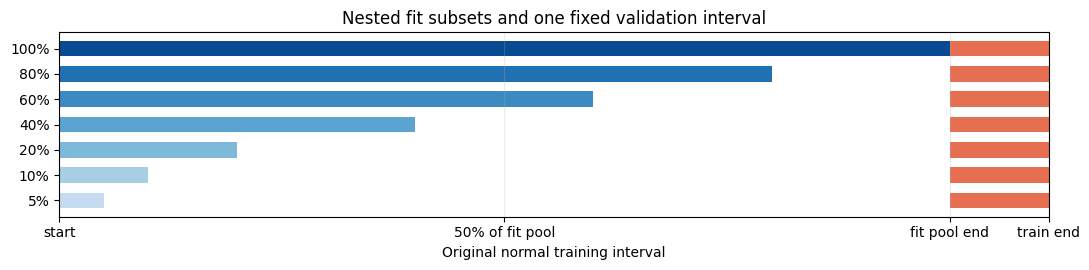

In [3]:
# 고정 validation과 중첩 fit subset의 관계
fig, axis = plt.subplots(figsize=(11, 2.8))
fit_pool_share = 0.9
colors = plt.cm.Blues([0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.9])
for row, (ratio, color) in enumerate(zip(RATIOS, colors)):
    axis.barh(row, fit_pool_share * ratio / 100, color=color, height=0.62)
    axis.barh(row, 0.1, left=fit_pool_share, color='#e76f51', height=0.62)
axis.set_yticks(range(len(RATIOS)), [f'{ratio}%' for ratio in RATIOS])
axis.set_xlim(0, 1)
axis.set_xticks([0, 0.45, 0.9, 1.0], ['start', '50% of fit pool', 'fit pool end', 'train end'])
axis.set_xlabel('Original normal training interval')
axis.set_title('Nested fit subsets and one fixed validation interval')
axis.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()


## 4. 모델별 고정 설정

| 모델 | 고정 설정 | 선정 기준 |
| --- | --- | --- |
| CI-AE | 채널별 독립 모델 19개, window 100, hidden 64·32, batch 128, 50 epoch | TSB-AD AE 실행 설정과 채널 관계 차단 대조군 정의 |
| LSTM-AD | window 100, hidden 20, 2 layers, horizon 1, batch 128, 최대 50 epoch | 채택한 TSB-AD LSTM-AD 구현 |
| USAD | window 10, latent 100, batch 128, 70 epoch, 두 Adam optimizer | USAD 논문·공식 코드와 프로젝트 전이 규칙 |
| GDN-GHL | window 5, topk 5, embedding 64, output hidden 128, batch 32 | GDN 논문·공식 실행 코드와 GHL 전이 규칙 |
| GDN-HAI | window 5, topk 22, embedding 64, output hidden 128, batch 32 | GDN 구조 유지와 HAI 전이 규칙 |

이 값은 GHL·HAI 테스트 성능으로 찾은 최적값이 아니다. USAD batch 128과 GDN topk 5·22도 공식 데이터셋별 값이 아니라 본실험 전에 고정한 프로젝트 전이값이다.

In [2]:
parameter_sources = pd.concat(
    [read_eda_csv(dataset, 'model_parameter_sources.csv') for dataset in ('ghl', 'hai')],
    ignore_index=True,
)
parameter_summary = (
    parameter_sources.groupby(['dataset', 'model'])
    .agg(
        parameter_count=('parameter', 'size'),
        fixed_across_all_ratios=('fixed_across_ratios', lambda values: values.astype(str).str.lower().eq('true').all()),
        source_choice_pending=('status', lambda values: values.eq('source_choice_required').sum()),
    )
    .reset_index()
)
transfer_rules = parameter_sources.query(
    "(model == 'USAD' and parameter == 'batch_size') or "
    "(model == 'GDN' and parameter == 'topk')"
)[[
    'dataset', 'model', 'parameter', 'reference_value', 'source', 'status'
]]
display(parameter_summary)
display(transfer_rules)


,dataset,model,parameter_count,fixed_across_all_ratios,source_choice_pending
0,GHL,CI-AE,13,True,0
1,GHL,GDN,20,True,0
2,GHL,LSTM-AD,12,True,0
3,GHL,USAD,15,True,0
4,HAI,GDN,20,True,0


,dataset,model,parameter,reference_value,source,status
28,GHL,USAD,batch_size,128,project fixed transfer rule,fixed
47,GHL,GDN,topk,5,project fixed transfer rule,fixed
67,HAI,GDN,topk,22,project fixed transfer rule,fixed


## 5. 데이터 무결성

| 항목 | GHL | HAI 23.05 |
| --- | ---: | ---: |
| 파일·세션 수 | 25 | 6 |
| 채널 수 | 19 | 86 |
| NaN | 0 | 0 |
| Inf | 0 | 0 |
| timestamp 검사 | 열이 없어 적용 불가 | 1초 간격, 중복·역전·불규칙 간격 0 |
| 채널 순서 재배열 | 10개 파일 | 없음 |

GHL은 센서 이름 집합은 같지만 10개 파일의 원본 열 순서가 달라 센서명 기준 공통 순서로 재배열한다. timestamp 열이 없으므로 sampling interval을 새로 입증했다고 쓰지 않는다. HAI는 여섯 세션의 센서 이름과 순서가 같고, 서로 다른 세션 사이에는 window를 만들지 않는다.

In [4]:
integrity_rows = []
for dataset in ('ghl', 'hai'):
    frame = read_eda_csv(dataset, 'data_integrity.csv')
    integrity_rows.append({
        'dataset': dataset.upper(),
        'files_or_sessions': len(frame),
        'channels': int(frame['feature_count'].iloc[0]),
        'nan': int(frame['missing_value_count'].sum()),
        'inf': int(frame['infinite_value_count'].sum()),
        'reordered_inputs': int(frame['input_reordered'].astype(str).str.lower().eq('true').sum()),
        'integrity_failures': int(frame['integrity_passed'].astype(str).str.lower().eq('false').sum()),
        'label_values_used': bool(frame['label_values_used'].astype(str).str.lower().eq('true').any()),
    })
display(pd.DataFrame(integrity_rows))


,dataset,files_or_sessions,channels,nan,inf,reordered_inputs,integrity_failures,label_values_used
0,GHL,25,19,0,0,10,0,False
1,HAI,6,86,0,0,0,0,False


## 6. 학습 비율에 따른 채널 변화

`constant`는 한 파일 또는 세션의 해당 범위에서 채널 값이 하나뿐이라는 뜻이다. `zero range`는 최솟값과 최댓값이 같고, `IQR=0`은 중앙 50%의 값이 같다는 뜻이다. IQR=0이어도 구간 전체가 constant일 필요는 없다.

### GHL: 25개 파일 × 19채널 = 475개 조합

| 비율 | fit subset constant | 변화가 관측된 조합 | IQR=0 |
| ---: | ---: | ---: | ---: |
| 5% | 246 | 229 | 279 |
| 10% | 150 | 325 | 326 |
| 20% | 145 | 330 | 320 |
| 40% | 0 | 475 | 151 |
| 60% | 0 | 475 | 150 |
| 80% | 0 | 475 | 150 |
| 100% | 0 | 475 | 150 |

고정 validation은 전 비율에서 constant 36개, IQR=0 조합 221개로 같았다.

### HAI: 훈련 4세션 × 86채널 = 344개 조합

| 비율 | 세션·채널 constant | pooled constant 채널 | pooled 변화 채널 |
| ---: | ---: | ---: | ---: |
| 5% | 130 | 26 | 60 |
| 10% | 124 | 26 | 60 |
| 20% | 105 | 20 | 66 |
| 40% | 100 | 20 | 66 |
| 60% | 86 | 20 | 66 |
| 80% | 84 | 20 | 66 |
| 100% | 82 | 20 | 66 |

세션별 constant와 pooled constant는 다른 통계다. 한 세션에서 값이 고정돼도 다른 세션에서 값이 달라지면 pooled 기준에서는 변화 채널이 된다.

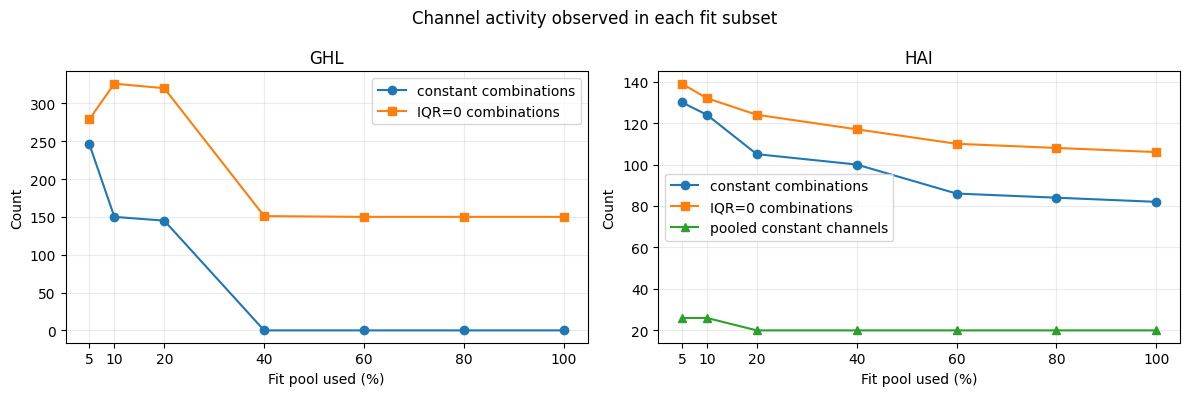

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, dataset in zip(axes, ('ghl', 'hai')):
    summary = read_eda_csv(dataset, 'constant_scope_summary.csv')
    fit = summary.loc[summary['scope'].eq('fit_subset')].sort_values('ratio')
    axis.plot(fit['ratio'], fit['constant_file_channel_combinations'], marker='o', label='constant combinations')
    axis.plot(fit['ratio'], fit['iqr_zero_file_channel_combinations'], marker='s', label='IQR=0 combinations')
    if dataset == 'hai':
        axis.plot(fit['ratio'], fit['pooled_constant_channel_count'], marker='^', label='pooled constant channels')
    axis.set_title(dataset.upper())
    axis.set_xlabel('Fit pool used (%)')
    axis.set_ylabel('Count')
    axis.set_xticks(RATIOS)
    axis.grid(alpha=0.25)
    axis.legend()
fig.suptitle('Channel activity observed in each fit subset')
plt.tight_layout()
plt.show()


## 7. scaler 적용 가능성

모든 GHL·HAI 비율에서 scaler 실행 준비 미충족 사례는 0개였다. scikit-learn의 MinMaxScaler는 constant와 zero-range 열도 오류 없이 처리한다. 두 값은 정보 변화가 없다는 경고이지 실행 실패 조건이 아니다. 값이 존재하고 모두 finite이면 `scaler_execution_ready=True`다.

constant 채널은 삭제하지 않는다. fit subset에서는 같은 값으로 변환되더라도 validation이나 test에서 학습 범위 밖 값이 나타날 수 있고, 채널을 빼면 모델 입력 순서와 GDN node 의미가 달라지기 때문이다.

In [6]:
scaler_rows = []
for dataset in ('ghl', 'hai'):
    frame = read_eda_csv(dataset, 'constant_scope_summary.csv')
    fit = frame.loc[frame['scope'].eq('fit_subset')]
    for row in fit.itertuples(index=False):
        scaler_rows.append({
            'dataset': dataset.upper(),
            'ratio': row.ratio,
            'constant': row.constant_file_channel_combinations,
            'zero_range': row.zero_range_file_channel_combinations,
            'nonfinite': row.nonfinite_file_channel_combinations,
            'scaler_not_ready': row.scaler_execution_not_ready_file_channel_combinations,
        })
display(pd.DataFrame(scaler_rows))


,dataset,ratio,constant,zero_range,nonfinite,scaler_not_ready
0,GHL,5,246,246,0,0
1,GHL,10,150,150,0,0
2,GHL,20,145,145,0,0
3,GHL,40,0,0,0,0
4,GHL,60,0,0,0,0
5,GHL,80,0,0,0,0
6,GHL,100,0,0,0,0
7,HAI,5,130,130,0,0
8,HAI,10,124,124,0,0
9,HAI,20,105,105,0,0


## 8. 유효 window와 계산 가능성

GHL의 모든 모델·비율·시계열과 HAI GDN의 모든 비율·세션에서 학습·validation window와 batch가 생성됐다. CI-AE의 수는 19개 채널별 모델의 window를 합산한 값이라 다변량 모델과 직접 비교하지 않는다.

| 데이터셋·모델 | 5% 학습 window | 100% 학습 window | 고정 validation window |
| --- | ---: | ---: | ---: |
| GHL CI-AE | 32,281–40,869 | 681,055–853,119 | 74,005–93,119 |
| GHL LSTM-AD | 1,698–2,150 | 35,844–44,900 | 3,894–4,900 |
| GHL USAD | 1,789–2,241 | 35,935–44,991 | 3,985–4,991 |
| GHL GDN | 1,793–2,245 | 35,939–44,995 | 3,989–4,995 |
| HAI GDN | 40,318 | 806,740 | 89,620 |

HAI GDN의 epoch당 optimizer update 상한은 5%에서 1,260회, 100%에서 25,211회다. 최대 epoch 전체의 상한은 각각 63,000회와 1,260,550회다. 실제 update 수와 실행 시간은 early stopping을 포함한 본실험 로그로 확정한다.

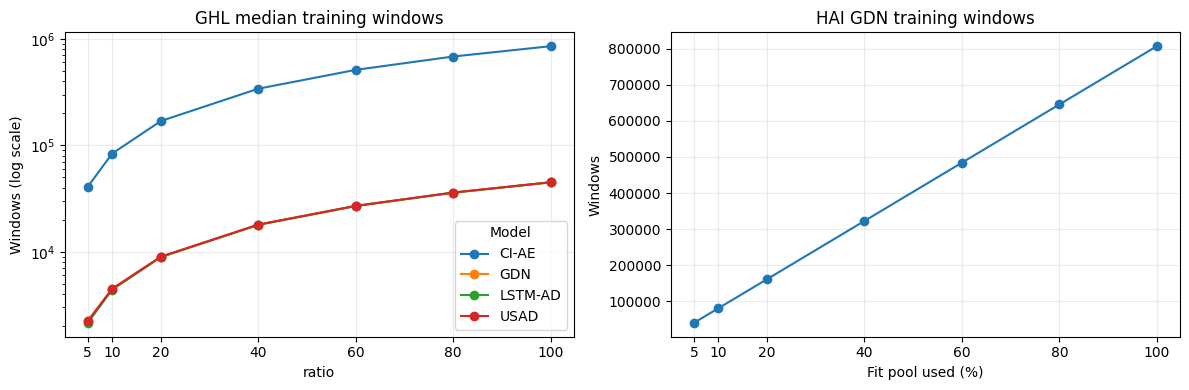

In [7]:
ghl_workload = read_eda_csv('ghl', 'training_workload_summary.csv')
hai_workload = read_eda_csv('hai', 'training_workload_summary.csv')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ghl_median = (
    ghl_workload.groupby(['ratio', 'model'])['train_window_count_all_models']
    .median().unstack('model')
)
ghl_median.plot(ax=axes[0], marker='o', logy=True)
axes[0].set_title('GHL median training windows')
axes[0].set_ylabel('Windows (log scale)')
axes[0].set_xticks(RATIOS)
axes[0].grid(alpha=0.25)
axes[0].legend(title='Model')

axes[1].plot(hai_workload['ratio'], hai_workload['train_window_count_all_models'], marker='o')
axes[1].set_title('HAI GDN training windows')
axes[1].set_xlabel('Fit pool used (%)')
axes[1].set_ylabel('Windows')
axes[1].set_xticks(RATIOS)
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()


## 9. 경계 보존

모든 모델과 비율에서 서로 다른 GHL 파일, HAI 세션, fit subset과 고정 validation, HAI test1과 test2 사이를 넘는 window는 0개였다. train과 validation을 원시 배열로 이어 붙여 window를 만들지 않고 각 범위에서 독립적으로 생성한다.

이 규칙은 작은 비율의 입력에 이후 시점이나 다른 세션의 값이 섞이는 일을 막는다.

In [8]:
boundary_rows = []
for dataset in ('ghl', 'hai'):
    frame = read_eda_csv(dataset, 'model_feasibility.csv')
    boundary_rows.append({
        'dataset': dataset.upper(),
        'fit_validation_crossings': int(frame['fit_validation_boundary_crossing_window_count'].sum()),
        'file_or_session_crossings': int(frame['file_or_session_boundary_crossing_window_count'].sum()),
        'infeasible_rows': int(frame['execution_feasible'].astype(str).str.lower().eq('false').sum()),
    })
display(pd.DataFrame(boundary_rows))


,dataset,fit_validation_crossings,file_or_session_crossings,infeasible_rows
0,GHL,0,0,0
1,HAI,0,0,0


## 10. 점수와 원 시간축 정렬

원 wrapper가 계산되지 않은 앞뒤 시점에 점수를 복제하더라도 본실험에서는 padding을 저장하지 않고 실제 core 점수만 남긴다.

| 모델 | window | 저장 점수 길이 | 첫 대응 index | 원 시계열 대응 범위 |
| --- | ---: | --- | ---: | --- |
| CI-AE | 100 | `L-99` | 50 | `source[50:L-49]` |
| LSTM-AD | 100 | `L-100` | 100 | `source[100:L]` |
| USAD | 10 | `L-9` | 5 | `source[5:L-4]` |
| GDN | 5 | `L-5` | 5 | `source[5:L]` |

CI-AE와 USAD는 window 재구성 오차를 오른쪽 중앙 시점에 둔다. LSTM-AD와 GDN은 다음 시점 예측 모델이므로 첫 점수가 index `W`에 대응한다. 채점기는 모델 이름으로 offset을 추측하지 않고 metadata의 `source_start`, `source_end_exclusive`와 `label_slice`를 읽는다.

In [9]:
alignment_rows = []
for dataset in ('ghl', 'hai'):
    frame = read_eda_csv(dataset, 'score_alignment.csv')
    alignment_rows.append({
        'dataset': dataset.upper(),
        'checked_rows': len(frame),
        'alignment_failures': int(frame['alignment_valid'].astype(str).str.lower().eq('false').sum()),
        'label_values_used': bool(frame['label_values_used'].astype(str).str.lower().eq('true').any()),
    })
display(pd.DataFrame(alignment_rows))


,dataset,checked_rows,alignment_failures,label_values_used
0,GHL,100,0,False
1,HAI,2,0,False


## 11. 합성 실행을 통한 구현 검증

원 wrapper의 분할·정규화·padding 충돌을 우회하는 모델별 얇은 adapter를 합성 데이터로 검사했다. 네 모델의 optimizer 갱신, checkpoint 저장·복원, 유한한 채널별 점수, raw·smoothed와 trainnorm·testnorm 조합, 정렬 metadata와 완료 판정을 확인했다. HAI형 GDN은 훈련 4세션·테스트 2세션 처리와 self-edge 포함·제외 인접행렬도 검사했다.

합성 점수와 checkpoint는 검증 뒤 지운다. 저장소에는 재실행 코드와 판정 요약 manifest만 남긴다. 이 결과는 실행 계약이 맞는다는 증거이며 실제 GHL·HAI 성능의 증거는 아니다.

In [10]:
implementation = json.loads(IMPLEMENTATION_MANIFEST.read_text(encoding='utf-8'))
implementation_rows = []
for model, status in implementation['models'].items():
    implementation_rows.append({
        'model': model,
        'passed': status['passed'],
        'checkpoint_restored': status['checkpoint_restored'],
        'optimizer_updates': status.get('optimizer_updates', 'multi-session check'),
        'labels_read': status['labels_read'],
    })
display(pd.DataFrame(implementation_rows))
display(pd.DataFrame([{
    'synthetic_only': implementation['synthetic_only'],
    'real_training_executed': implementation['real_training_executed'],
    'overall_passed': implementation['success'],
}]))


,model,passed,checkpoint_restored,optimizer_updates,labels_read
0,CI-AE,True,True,19,False
1,LSTM-AD,True,True,2,False
2,USAD,True,True,4,False
3,GDN,True,True,8,False
4,GDN-HAI-multisession,True,True,multi-session check,False


,synthetic_only,real_training_executed,overall_passed
0,True,False,True


## 12. Tier 2 최종 판정

| 판정 항목 | 결과 |
| --- | --- |
| 모델별 파라미터와 출처 | 확정 |
| GHL·HAI 7개 학습 비율 | 확정 |
| 비율별 동일 설정 | 확정 |
| 데이터 무결성 | 통과 |
| fit-only MinMax scaling | 적용 가능 |
| 유효 window·batch | 모든 조건에서 생성 가능 |
| 세션·분할 경계 침범 | 0개 |
| 점수·라벨 정렬 | 통과 |
| 모델 adapter와 저장 계약 | 합성 검증 통과 |
| 실제 성능 평가 | 미실행 |

Tier 2의 파라미터와 실행 규격은 확정한다. 실제 실험에서는 학습 데이터 비율만 바꾸며, 성능이 낮다는 이유로 해당 비율의 설정을 다시 튜닝하지 않는다.

## 13. 해석상의 한계

- 유효 window와 합성 실행 성공은 실제 이상 탐지 성능을 보장하지 않는다.
- 모델끼리 같은 파라미터를 쓰는 비교가 아니라, 모델별 고정 설정을 모든 비율에서 유지하는 비교다.
- USAD batch 128과 GDN topk 5·22는 공식 GHL·HAI 최적값이 아니라 사전 전이값이다.
- 낮은 비율의 constant 채널 증가는 관측 범위가 좁다는 뜻일 뿐 성능 저하의 원인을 확정하지 않는다.
- GHL은 timestamp가 없어 실제 sampling interval의 규칙성을 확인하지 못했다.
- workload의 최대 update는 early stopping이 없다고 본 상한이다.

## 14. 재현 자료와 manifest 상태

두 EDA manifest는 같은 run ID로 생성됐다. 생성 시점의 상태는 `eda_generation_success=True`, `parameter_eda_closed=True`, `tier2_execution_ready=False`였다. 마지막 값은 당시 adapter와 전체 import가 남아 있었기 때문이다. 이후 별도 합성 구현 manifest에서 네 adapter와 HAI 다중 세션형 GDN을 검증했다. EDA는 다시 생성하지 않았다.

아래 셀은 EDA CSV·보고서 checksum, 일곱 비율, label 미사용, 실데이터 학습 미실행과 현재 모델 소스 hash를 다시 대조한다.

In [11]:
def sha256(path):
    return hashlib.sha256(path.read_bytes()).hexdigest()

manifest_rows = []
for dataset in ('ghl', 'hai'):
    manifest = read_eda_manifest(dataset)
    output_root = EDA_ROOT / dataset / 'tier2_eda'
    checksums_match = all(
        sha256(output_root / item['path']) == item['sha256']
        for item in manifest['generated_files']
    )
    manifest_rows.append({
        'dataset': dataset.upper(),
        'run_id': manifest['run_id'],
        'ratios': manifest['ratios_percent'],
        'output_checksums_match': checksums_match,
        'eda_generation_success': manifest['eda_generation_success'],
        'parameter_eda_closed': manifest['parameter_eda_closed'],
        'tier2_execution_ready_at_eda_time': manifest['tier2_execution_ready'],
        'labels_used': manifest['label_values_used'],
        'real_model_training': manifest['model_training_executed'],
    })

current_model_hashes_match = all(
    sha256(REPOSITORY_ROOT / path) == expected
    for path, expected in implementation['source_identity']['local_model_sha256'].items()
)
display(pd.DataFrame(manifest_rows))
display(pd.DataFrame([{
    'paired_eda_run_id': len({row['run_id'] for row in manifest_rows}) == 1,
    'implementation_manifest_passed': implementation['success'],
    'current_model_hashes_match': current_model_hashes_match,
    'real_training_executed': implementation['real_training_executed'],
}]))


,dataset,run_id,ratios,output_checksums_match,eda_generation_success,parameter_eda_closed,tier2_execution_ready_at_eda_time,labels_used,real_model_training
0,GHL,tier2-eda-20260819T114344Z-973ac494,"[5, 10, 20, 40, 60, 80, 100]",True,True,True,False,False,False
1,HAI,tier2-eda-20260819T114344Z-973ac494,"[5, 10, 20, 40, 60, 80, 100]",True,True,True,False,False,False


,paired_eda_run_id,implementation_manifest_passed,current_model_hashes_match,real_training_executed
0,True,True,True,False


### 주요 근거 파일

| 내용 | GHL | HAI |
| --- | --- | --- |
| 데이터 무결성 | `tier2_eda/csv/data_integrity.csv` | `tier2_eda/csv/data_integrity.csv` |
| 채널 상태 | `tier2_eda/csv/constant_scope_summary.csv` | `tier2_eda/csv/constant_scope_summary.csv` |
| scaler 상세 | `tier2_eda/csv/channel_scaling_readiness.csv` | `tier2_eda/csv/channel_scaling_readiness.csv` |
| window·batch·update | `tier2_eda/csv/training_workload_summary.csv` | `tier2_eda/csv/training_workload_summary.csv` |
| 경계와 적용 가능성 | `tier2_eda/csv/model_feasibility.csv` | `tier2_eda/csv/model_feasibility.csv` |
| 점수 정렬 | `tier2_eda/csv/score_alignment.csv` | `tier2_eda/csv/score_alignment.csv` |
| 파라미터 출처 | `tier2_eda/csv/model_parameter_sources.csv` | `tier2_eda/csv/model_parameter_sources.csv` |
| EDA manifest | `tier2_eda/json/eda_manifest.json` | `tier2_eda/json/eda_manifest.json` |

합성 구현 판정은 `experiments/checks/tier2_implementation/implementation_manifest.json`에 있다. 원시 합성 점수와 checkpoint는 보존하지 않으며 `tests/checks/run_tier2_dryrun.py`로 다시 검증한다.

## 15. 결론

Tier 2 EDA는 사전에 고정한 모델 설정이 GHL과 HAI의 모든 학습 데이터 비율에서 계산 가능한지 확인했다. 두 데이터셋 모두 데이터 무결성, 유효 window 생성, 경계 보존과 점수 정렬 조건을 만족했다.

낮은 비율에서는 constant 채널이 늘어 정상 공정 변화의 관측 범위가 좁아졌다. 이 현상은 이후 성능 변화를 설명할 후보 요인이지만 실제 관계는 본실험 결과로 검증해야 한다.

네 모델 adapter와 공통 점수 저장 계약은 합성 데이터에서 검증했다. Tier 2의 파라미터와 실행 규격은 확정하며 이후 실험에서는 학습 데이터 비율만 변경한다. 실제 GHL·HAI 학습은 아직 시작하지 않았다.

# 부록

아래 셀은 본문에서 줄인 파라미터·window 출처표와 workload 원표를 그대로 불러온다. 채널별 scaling 표는 GHL 9,975행, HAI 7,224행이라 전체를 본문에 펼치지 않는다.

In [12]:
appendix_tables = {
    'GHL parameter sources': read_eda_csv('ghl', 'model_parameter_sources.csv'),
    'HAI parameter sources': read_eda_csv('hai', 'model_parameter_sources.csv'),
    'GHL window sources': read_eda_csv('ghl', 'model_window_sources.csv'),
    'HAI window sources': read_eda_csv('hai', 'model_window_sources.csv'),
    'GHL workload': read_eda_csv('ghl', 'training_workload_summary.csv'),
    'HAI workload': read_eda_csv('hai', 'training_workload_summary.csv'),
}
for title, frame in appendix_tables.items():
    print(title)
    display(frame)


GHL parameter sources


,dataset,model,parameter,reference_value,source_priority,source,selection_reason,fixed_across_ratios,status
0,GHL,CI-AE,model_structure,19 separate univariate autoencoders,5,project control definition,채널 간 정보 공유를 원리적으로 차단한다.,True,adapter_required
1,GHL,CI-AE,input_window,100,4,TSB-AD run_AutoEncoder,채택 wrapper의 실제 입력 길이다.,True,verified
2,GHL,CI-AE,hidden_and_latent,"64,32; latent=32",4,TSB-AD run_AutoEncoder,wrapper가 넘기는 hidden_neurons를 그대로 쓴다.,True,verified
3,GHL,CI-AE,activation_and_regularization,ReLU; BatchNorm; dropout=0.2,4,TSB-AD AutoEncoder,채택 구현의 구조를 그대로 쓴다.,True,verified
4,GHL,CI-AE,batch_size,128,4,TSB-AD run_AutoEncoder,wrapper가 클래스 기본값 32를 128로 덮어쓴다.,True,verified
5,GHL,CI-AE,max_epochs,50,4,TSB-AD run_AutoEncoder,wrapper가 클래스 기본값 100을 50으로 덮어쓴다.,True,verified
6,GHL,CI-AE,optimizer,"Adam(lr=0.001, weight_decay=1e-5)",4,TSB-AD AutoEncoder,채택 코드의 학습 규칙이다.,True,verified
7,GHL,CI-AE,early_stopping,none; use final epoch state,4,TSB-AD AutoEncoder,원본은 state_dict를 복사하지 않아 최저 손실 시점이 아니라 마지막 epoc...,True,verified
8,GHL,CI-AE,loss,MSE reconstruction,4,TSB-AD AutoEncoder,채택 코드의 학습 손실이다.,True,verified
9,GHL,CI-AE,anomaly_score,mean absolute reconstruction error over window...,5,project score contract,학습 손실은 MSE로 두고 출력 점수만 공통 절대오차 계약에 맞춘다.,True,adapter_required


HAI parameter sources


,dataset,model,parameter,reference_value,source_priority,source,selection_reason,fixed_across_ratios,status
0,HAI,GDN,model_structure,learned sensor graph; one-step forecast,1,GDN paper,센서 관계를 학습하는 주 모델 정의다.,True,verified
1,HAI,GDN,input_window,5,1,GDN paper SWaT/WADI experiments,논문 실험값을 CLI 기본 15보다 우선한다.,True,verified
2,HAI,GDN,embedding_dimension,64,2,d-ailin/GDN run.sh,공식 실행 스크립트 값이다.,True,verified
3,HAI,GDN,output_hidden_dimension,128,2,d-ailin/GDN run.sh,공식 실행 스크립트가 CLI 기본 256을 덮어쓴다.,True,verified
4,HAI,GDN,output_layer_count,1,2,d-ailin/GDN run.sh,공식 실행 스크립트 값이다.,True,verified
5,HAI,GDN,heads,1,4,pinned GraGOD implementation,현재 채택 구현의 단일 head 구조다.,True,verified
6,HAI,GDN,dropout,0.2,2,d-ailin/GDN model.py,원 저자 모델의 출력 dropout 값이다. GraGOD는 같은 인자를 attent...,True,local_source_mismatch
7,HAI,GDN,topk,22,5,project fixed transfer rule,GHL·HAI 성능을 보기 전에 채널 수에 맞춰 고정한 프로젝트 값이다.,True,fixed
8,HAI,GDN,batch_size,32,2,d-ailin/GDN run.sh,공식 실행 스크립트 값이다.,True,verified
9,HAI,GDN,train_and_evaluation_stride,train=1; evaluation=1,2,d-ailin/GDN run.sh and TimeDataset.py,run.sh의 SLIDE_STRIDE=1과 평가 구간의 고정 stride 1을 따른다.,True,verified


GHL window sources


...

,dataset,model,source_type,source,window_value,applies_to,actual_override,source_commit,project_selected,reason
0,HAI,GDN,논문,GDN AAAI 2021,5,SWaT·WADI,해당 없음,paper,True,논문 실험값을 우선한다.
1,HAI,GDN,공식 코드,d-ailin/GDN main.py 기본값,15,명령행 기본값,기본값 사용 시 15,9853899da860682669a134e4af315d036aab4eca,False,논문 실험값 5와 다르므로 채택하지 않는다.
2,HAI,GDN,현재 config,configs/gdn_hyperparams.yaml,5,GHL·HAI,명시값 5,project,True,논문값과 일치하며 모든 비율과 두 데이터셋에 고정한다.


GHL workload


,dataset,training_scope,ratio,model,training_unit,source_session_count,model_instance_count,train_window_count_per_model,train_window_count_all_models,validation_window_count_per_model,...,validation_batches_per_model,validation_batches_all_models,max_epochs,maximum_optimizer_updates,early_stopping_rule,workload_status,actual_optimizer_updates_status,fit_validation_boundary_crossing_window_count,session_boundary_crossing_window_count,windows_excluded_to_preserve_session_boundaries
0,GHL,series_01,5,CI-AE,one_model_per_channel,1,19,2151,40869,4901,...,39,741,50,15200,none,fixed_for_pretraining_audit,execution log required,0,0,0
1,GHL,series_01,5,GDN,one_multivariate_model,1,1,2245,2245,4995,...,157,157,50,3550,patience=10,fixed_for_pretraining_audit,execution log required,0,0,0
2,GHL,series_01,5,LSTM-AD,one_multivariate_model,1,1,2150,2150,4900,...,39,39,50,850,patience=3,fixed_for_pretraining_audit,execution log required,0,0,0
3,GHL,series_01,5,USAD,one_multivariate_model,1,1,2241,2241,4991,...,39,39,70,2520,none,fixed_project_transfer_rule,batch_size fixed by project transfer rule; exe...,0,0,0
4,GHL,series_01,10,CI-AE,one_model_per_channel,1,19,4401,83619,4901,...,39,741,50,32300,none,fixed_for_pretraining_audit,execution log required,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,GHL,series_25,80,USAD,one_multivariate_model,1,1,35991,35991,4991,...,39,39,70,39480,none,fixed_project_transfer_rule,batch_size fixed by project transfer rule; exe...,0,0,0
696,GHL,series_25,100,CI-AE,one_model_per_channel,1,19,44901,853119,4901,...,39,741,50,332500,none,fixed_for_pretraining_audit,execution log required,0,0,0
697,GHL,series_25,100,GDN,one_multivariate_model,1,1,44995,44995,4995,...,157,157,50,70350,patience=10,fixed_for_pretraining_audit,execution log required,0,0,0
698,GHL,series_25,100,LSTM-AD,one_multivariate_model,1,1,44900,44900,4900,...,39,39,50,17550,patience=3,fixed_for_pretraining_audit,execution log required,0,0,0


HAI workload


,dataset,training_scope,ratio,model,training_unit,source_session_count,model_instance_count,train_window_count_per_model,train_window_count_all_models,validation_window_count_per_model,...,validation_batches_per_model,validation_batches_all_models,max_epochs,maximum_optimizer_updates,early_stopping_rule,workload_status,actual_optimizer_updates_status,fit_validation_boundary_crossing_window_count,session_boundary_crossing_window_count,windows_excluded_to_preserve_session_boundaries
0,HAI,all_train_sessions,5,GDN,one_model_over_all_train_sessions,4,1,40318,40318,89620,...,2801,2801,50,63000,patience=10,fixed_for_pretraining_audit,execution log required,0,0,15
1,HAI,all_train_sessions,10,GDN,one_model_over_all_train_sessions,4,1,80656,80656,89620,...,2801,2801,50,126050,patience=10,fixed_for_pretraining_audit,execution log required,0,0,15
2,HAI,all_train_sessions,20,GDN,one_model_over_all_train_sessions,4,1,161332,161332,89620,...,2801,2801,50,252100,patience=10,fixed_for_pretraining_audit,execution log required,0,0,15
3,HAI,all_train_sessions,40,GDN,one_model_over_all_train_sessions,4,1,322684,322684,89620,...,2801,2801,50,504200,patience=10,fixed_for_pretraining_audit,execution log required,0,0,15
4,HAI,all_train_sessions,60,GDN,one_model_over_all_train_sessions,4,1,484036,484036,89620,...,2801,2801,50,756350,patience=10,fixed_for_pretraining_audit,execution log required,0,0,15
5,HAI,all_train_sessions,80,GDN,one_model_over_all_train_sessions,4,1,645388,645388,89620,...,2801,2801,50,1008450,patience=10,fixed_for_pretraining_audit,execution log required,0,0,15
6,HAI,all_train_sessions,100,GDN,one_model_over_all_train_sessions,4,1,806740,806740,89620,...,2801,2801,50,1260550,patience=10,fixed_for_pretraining_audit,execution log required,0,0,15
